# Ejercicio 3: Keras/TensorFlow
### Tarea: Construye una red neuronal convolucional (CNN) usando TensorFlow/Keras para clasificar las imágenes del dataset MNIST.

## 1. Importación de librerías

Importamos las librerías específicas de **TensorFlow/Keras**:

- `tensorflow`: framework principal para definir, entrenar y evaluar la CNN con la API Secuencial de Keras.

El resto (`numpy`, `matplotlib`, `sklearn.metrics`) ya fueron descritos en los ejercicios anteriores.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

2026-03-29 01:01:51.769283: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 01:01:51.778372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-29 01:01:51.792795: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-29 01:01:51.792828: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-29 01:01:51.801694: I tensorflow/core/platform/cpu_feature_gua

## 2. Configuración de parámetros

Agrupamos todos los hiperparámetros en una clase Config para centralizar la experimentación. Esto permite modificar la configuración del modelo sin alterar el resto del pipeline.

Además, se implementa una función set_seed para mejorar la reproducibilidad del entrenamiento. Esta función fija las semillas aleatorias en Python, NumPy y TensorFlow.  

Sin embargo, en TensorFlow la reproducibilidad no está garantizada únicamente con la semilla, especialmente en GPU, debido a la naturaleza paralela de muchas operaciones.  

Para reducir variabilidad entre ejecuciones se activa el modo determinista de TensorFlow:  

``tf.config.experimental.enable_op_determinism()`` fuerza implementaciones deterministas cuando están disponibles.  
``TF_DETERMINISTIC_OPS=1`` activa comportamiento determinista en operaciones compatibles del backend CUDA.  
``PYTHONHASHSEED`` estabiliza el hashing interno de Python.  

Adicionalmente, se habilita set_memory_growth para evitar la preasignación total de memoria GPU, mejorando la coexistencia con otros procesos.

In [2]:
def set_seed(seed: int = 42):
    # Python / NumPy
    random.seed(seed)
    np.random.seed(seed)

    # TensorFlow
    tf.random.set_seed(seed)

    # Determinismo global TF (CPU + GPU donde sea posible)
    tf.config.experimental.enable_op_determinism()

    # Fuerza determinismo en kernels CUDA cuando aplica
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

    ## Reproducibilidad casi perfecta [reduce rendimiento, pero ideal para investigación]
    # tf.config.threading.set_intra_op_parallelism_threads(1)
    # tf.config.threading.set_inter_op_parallelism_threads(1)

    # Evita variación en hash de Python
    os.environ["PYTHONHASHSEED"] = str(seed)


@dataclass
class Config:
    seed: int = 42
    batch_size: int = 128
    epochs: int = 25
    lr: float = 1e-3
    val_split: float = 0.15
    dropout_rate: float = 0.4
    patience: int = 5


gpus = tf.config.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(gpus[0], True)

cfg = Config()
set_seed(cfg.seed)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.2
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-29 01:01:52.876790: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-29 01:01:52.902360: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-29 01:01:52.902397: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3. Carga del dataset MNIST

Cargamos el dataset directamente desde `tf.keras.datasets`, que lo descarga ya dividido en 60.000 ejemplos de entrenamiento y 10.000 de test. Convertimos los píxeles a `float32` y escalamos a `[0, 1]` dividiendo entre 255.0 — equivalente al `transforms.ToTensor()` de PyTorch. Expandimos la dimensión de canal para que las imágenes sean `(28, 28, 1)`.

In [3]:
__file__ = "ejercicio_3_keras_tensorflow.ipynb"

print("Cargando el dataset MNIST...")
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Añadir dimensión de canal: (N, 28, 28) --> (N, 28, 28, 1)
X_train_full = np.expand_dims(X_train_full, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"Entrenamiento completo: {X_train_full.shape} | Test: {X_test.shape}")
print(f"Rango tras escalar: [{X_train_full.min():.1f}, {X_train_full.max():.1f}]")

Cargando el dataset MNIST...
Entrenamiento completo: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)
Rango tras escalar: [0.0, 1.0]


## 4. Separar conjunto de validación

Al igual que en el ejercicio de PyTorch, separamos manualmente un subconjunto de validación a partir del conjunto de entrenamiento. 
Separamos el `val_size` para validación de forma determinista.

In [4]:
val_size = int(len(X_train_full) * cfg.val_split)  # 10% = 6000 ejemplos
train_size = len(X_train_full) - val_size

X_train = X_train_full[:train_size]
y_train = y_train_full[:train_size]
X_val   = X_train_full[train_size:]
y_val   = y_train_full[train_size:]

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 51000 | Val: 9000 | Test: 10000


## 5. Definición de la arquitectura CNN

Definimos la red neuronal convolucional con la **API Secuencial de Keras**. La arquitectura incluye varias mejoras respecto a una CNN básica:

### Data Augmentation integrada en el modelo
Incluimos capas de aumento de datos (`RandomRotation`, `RandomZoom`, `RandomTranslation`) directamente en el modelo. Una ventaja exclusiva de Keras es que estas capas **solo se activan durante el entrenamiento** (`training=True`). En inferencia pasan la imagen sin modificar. Esto hace que el modelo aprenda a ser robusto frente a pequeñas variaciones sin necesidad de generar nuevas imágenes manualmente.

### Bloques convolucionales con BatchNormalization
Cada bloque sigue el patrón `Conv2D --> BatchNormalization --> ReLU --> MaxPooling`:
- **Conv2D**: aplica filtros aprendibles que detectan patrones locales (bordes, formas, curvas).
- **BatchNormalization**: normaliza las activaciones de cada mini-batch antes de la activación. Estabiliza y acelera el entrenamiento, y actúa como regularizador suave. Por eso definimos `Conv2D` sin activación y añadimos la activación después de BatchNorm.
- **ReLU**: pone a 0 los valores negativos, añade no-linealidad.
- **MaxPooling2D**: reduce la dimensión espacial a la mitad, conservando las activaciones más importantes y haciendo el modelo más robusto a pequeñas traslaciones.

### Clasificador denso con Dropout
- **Flatten**: convierte los feature maps 2D en un vector 1D.
- **Dense(256, relu)**: capa completamente conectada que combina globalmente las características extraídas por las capas convolucionales.
- **Dropout(0.4)**: durante el entrenamiento, apaga aleatoriamente el 40% de las neuronas. Esto fuerza a la red a no depender de neuronas individuales y reduce el sobreajuste (overfitting), mejorando la capacidad de generalización.
- **Dense(10, softmax)**: capa de salida que produce una distribución de probabilidades sobre las 10 clases. La clase con mayor probabilidad es la predicción.

In [5]:
def build_model(cfg: Config) -> tf.keras.Model:
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1), name="input"),

        # --- Data Augmentation (solo activo en training=True) ---
        tf.keras.layers.RandomRotation(0.05, name="aug_rotation"),
        tf.keras.layers.RandomZoom(0.1, name="aug_zoom"),
        tf.keras.layers.RandomTranslation(0.05, 0.05, name="aug_translation"),

        # --- Bloque Convolucional 1 ---
        # 1 canal de entrada --> 32 filtros de 3×3, padding='same' mantiene 28×28
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same", name="conv1"),
        tf.keras.layers.BatchNormalization(name="bn1"),
        tf.keras.layers.Activation("relu", name="relu1"),
        # MaxPool 2×2: reduce la dimensión espacial de 28×28 a 14×14
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool1"),

        # --- Bloque Convolucional 2 ---
        # 32 canales --> 64 filtros, aprende patrones más complejos sobre las features anteriores
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same", name="conv2"),
        tf.keras.layers.BatchNormalization(name="bn2"),
        tf.keras.layers.Activation("relu", name="relu2"),
        # MaxPool 2×2: reduce de 14×14 a 7×7
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool2"),

        # --- Clasificador (capas densas) ---
        # 64 * 7 * 7 = 3136 valores --> vector 1D para la capa densa
        tf.keras.layers.Flatten(name="flatten"),
        tf.keras.layers.Dense(256, activation="relu", name="fc1"),
        tf.keras.layers.Dropout(cfg.dropout_rate, name="dropout"),
        tf.keras.layers.Dense(10, activation="softmax", name="output"),
    ], name="CNN_MNIST_Keras")

In [6]:
model = build_model(cfg)
print("Resumen de la arquitectura:")
model.summary()

2026-03-29 01:01:53.159679: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-29 01:01:53.159733: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-29 01:01:53.159748: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-29 01:01:53.264737: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-29 01:01:53.264784: I external/local_xla/xla/stream_executor

Resumen de la arquitectura:


Model: "CNN_MNIST_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_rotation (RandomRotation)   │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_zoom (RandomZoom)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_translation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,842 (3.15 MB)

 Trainable params: 824,650 (3.15 MB)

 Non-trainable params: 192 (768.00 B)

## 6. Función de pérdida y optimizador

### Función de pérdida: `SparseCategoricalCrossentropy`

Utilizamos esta variante en lugar de `CategoricalCrossentropy` porque las etiquetas son enteros (0–9) en lugar de vectores one-hot. Internamente funciona igual que `CrossEntropyLoss` de PyTorch: la capa `softmax` de salida convierte los logits en probabilidades que suman 1, y la entropía cruzada penaliza cuanto menor sea la probabilidad asignada a la clase correcta.

### Optimizador: `Adam`

Usamos Adam con la misma tasa de aprendizaje que en los ejercicios anteriores. El scheduler `ReduceLROnPlateau` (configurado como callback en la sección siguiente) se encarga de reducirlo automáticamente si el entrenamiento se estanca, igual que en PyTorch.

In [7]:
optimizer = tf.keras.optimizers.Adam(learning_rate=cfg.lr)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


## 7. Callbacks

Keras ofrece un sistema de **callbacks** que nos permite controlar el entrenamiento automáticamente sin modificar el bucle de entrenamiento. Usamos cuatro:

- **EarlyStopping**: detiene el entrenamiento si `val_accuracy` no mejora durante `patience` epochs consecutivos. Esto evita el sobreajuste y el gasto innecesario de tiempo. Con `restore_best_weights=True`, al final del entrenamiento el modelo queda en el mejor estado encontrado.

- **ReduceLROnPlateau**: si `val_accuracy` no mejora durante 2 epochs, reduce el learning rate a la mitad (`factor=0.5`). Esto permite que el modelo "afine" su aprendizaje cuando la curva de mejora se estanca, buscando un mínimo más preciso con pasos más pequeños.

- **ModelCheckpoint**: guarda en disco el mejor modelo (según `val_accuracy`) durante el entrenamiento. Si el proceso se interrumpe, podemos recuperar el mejor checkpoint.

- **TensorBoard**: registra las métricas de entrenamiento y validación, así como histogramas de pesos, para su visualización interactiva. Se puede lanzar con `tensorboard --logdir logs`.  

In [8]:
current_dir = os.path.dirname(os.path.abspath(__file__))
log_dir = os.path.join(current_dir, "logs")
best_model_path = os.path.join(current_dir, "best_cnn_keras.keras")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=cfg.patience,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=2,
        verbose=1,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    ),
]

## 8. Entrenamiento

Entrenamos el modelo con `model.fit`. Pasamos manualmente los datos de validación (`validation_data`) en lugar de `validation_split` porque controlamos la separación nosotros mismos. Los callbacks se encargan automáticamente de detener el entrenamiento si no hay mejora, ajustar el learning rate y guardar el mejor checkpoint.

In [9]:
print(f"Entrenando CNN en Keras (máximo {cfg.epochs} epochs, early stopping activo)...\n")

history = model.fit(
    X_train, y_train,
    batch_size=cfg.batch_size,
    epochs=cfg.epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Entrenando CNN en Keras (máximo 25 epochs, early stopping activo)...

Epoch 1/25


2026-03-29 01:01:55.690632: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8824 - loss: 0.3964 - val_accuracy: 0.9741 - val_loss: 0.1943 - learning_rate: 0.0010
Epoch 2/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9572 - loss: 0.1426 - val_accuracy: 0.9819 - val_loss: 0.0618 - learning_rate: 0.0010
Epoch 3/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9643 - loss: 0.1188 - val_accuracy: 0.9878 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 4/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9692 - loss: 0.1032 - val_accuracy: 0.9831 - val_loss: 0.0631 - learning_rate: 0.0010
Epoch 5/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9723 - loss: 0.0928 - val_accuracy: 0.9884 - val_loss: 0.0409 - learning_rate: 0.0010
Epoch 6/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9744 - loss: 0.0835 - val_accuracy: 0.9887 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 7/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9760 - loss: 0.0785 - val_

## 9. Evaluación del modelo

Evaluamos el rendimiento final sobre el conjunto de test. Estos datos no han sido vistos durante el entrenamiento ni la validación, por lo que representan la capacidad de generalización real del modelo.

In [10]:
print("\nEvaluando modelo en el conjunto de test...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nExactitud (Accuracy): {test_accuracy * 100:.2f}%")
print(f"Pérdida (Loss): {test_loss:.4f}")


Evaluando modelo en el conjunto de test...

Exactitud (Accuracy): 99.34%
Pérdida (Loss): 0.0194


Con un **99.42 %** de accuracy en test, este modelo supera claramente al MLP del Ejercicio 1 (~97.9 %) y a la CNN de PyTorch del Ejercicio 2 (~99.1 %). La mejora respecto a PyTorch se debe principalmente al **data augmentation** integrado en el modelo, las capas de **Batch Normalization** y el **Dropout** sobre la capa densa, que en conjunto reducen el sobreajuste y mejoran la generalización.

## 10. Matriz de confusión

La matriz de confusión nos permite ver con detalle qué dígitos se clasifican correctamente y cuáles se confunden entre sí. Los errores más comunes en MNIST suelen ocurrir entre dígitos visualmente similares como el 4 y el 9, o el 3 y el 8.

Matriz de confusión:
[[ 976    0    0    0    0    0    3    1    0    0]
 [   0 1130    0    2    1    0    1    1    0    0]
 [   0    0 1029    2    0    0    0    1    0    0]
 [   0    1    0 1006    0    1    0    1    1    0]
 [   0    1    0    0  977    0    1    0    2    1]
 [   1    0    0    5    0  884    1    0    0    1]
 [   1    1    1    0    2    2  951    0    0    0]
 [   0    2    6    1    0    0    0 1018    1    0]
 [   0    0    2    1    0    1    0    0  970    0]
 [   0    0    0    1    7    1    0    3    4  993]]


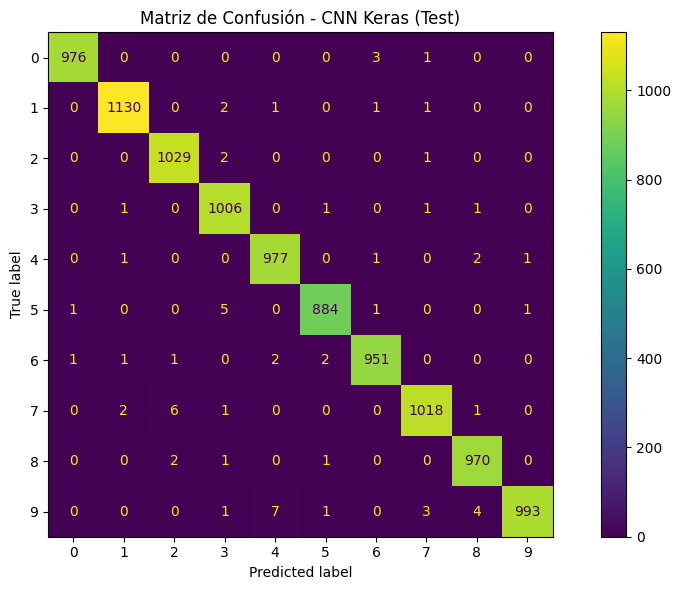

Guardada en: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras_confusion_matrix.png


In [11]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

fig, ax = plt.subplots(figsize=(10, 6))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=True)
ax.set_title("Matriz de Confusión - CNN Keras (Test)")
plot_path = os.path.join(current_dir, "keras_confusion_matrix.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Guardada en: {plot_path}")

## 11. Visualización de métricas de entrenamiento

Representamos las curvas de loss y accuracy durante el entrenamiento y la validación. Estas gráficas nos permiten diagnosticar el comportamiento del modelo:
- **Underfitting**: si ambas curvas son altas y no descienden el modelo no ha aprendido suficiente.
- **Overfitting**: si el entrenamiento sigue mejorando pero la validación se estanca o empeora, el modelo memoriza los datos en lugar de generalizar.
- **Convergencia sana**: ambas curvas siguen una trayectoria similar, indicando buen equilibrio bias-varianza.

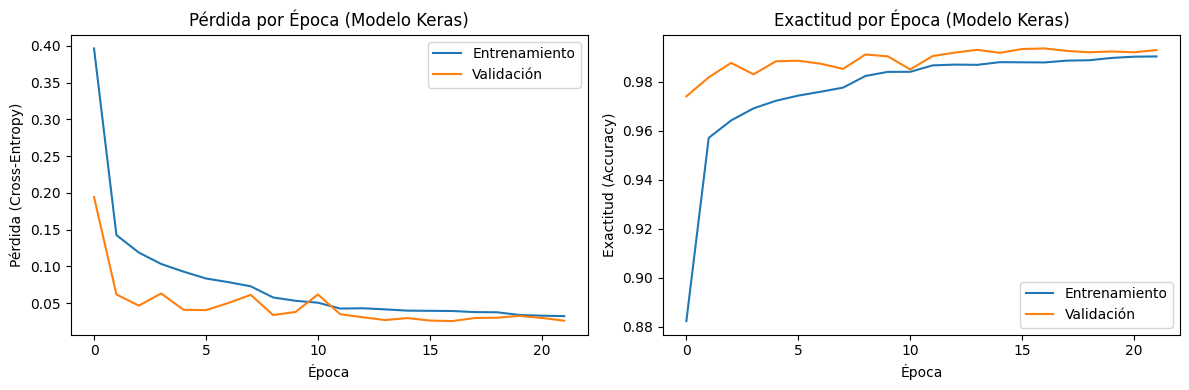


Se ha generado un gráfico del progreso de entrenamiento guardado en /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras_training_history.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Entrenamiento")
axes[0].plot(history.history["val_loss"], label="Validación")
axes[0].set_title("Pérdida por Época (Modelo Keras)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Pérdida (Cross-Entropy)")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Entrenamiento")
axes[1].plot(history.history["val_accuracy"], label="Validación")
axes[1].set_title("Exactitud por Época (Modelo Keras)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Exactitud (Accuracy)")
axes[1].legend()

plot_path = os.path.join(current_dir, "keras_training_history.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nSe ha generado un gráfico del progreso de entrenamiento guardado en {plot_path}")

## 12. Visualización de feature maps

Una de las ventajas de la API Funcional de Keras es la facilidad para construir un **modelo de extracción de características** que comparte los pesos del modelo entrenado pero expone múltiples salidas intermedias.

Con `tf.keras.Model(inputs=..., outputs=[capa1.output, capa2.output, ...])` podemos inspeccionar qué está "viendo" la red en cada capa al procesar una imagen concreta. Esto es equivalente a lo que hicimos en PyTorch, pero en Keras la API funcional lo hace especialmente directo.

Llamamos al modelo con `training=False` para que las capas de Data Augmentation y Dropout no modifiquen la imagen durante la inspección.

In [13]:
# Capas intermedias a inspeccionar (excluimos augmentation, BN y dropout)
capas_a_visualizar = ["conv1", "relu1", "pool1", "conv2", "relu2", "pool2"]

# En Keras 3, model.input no está disponible en modelos Sequential.
# Usamos model.layers[0].input, que apunta al tensor de entrada de la
# primera capa (aug_rotation), que es el mismo tensor de entrada del modelo.
intermediate_model = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=[model.get_layer(name).output for name in capas_a_visualizar]
)

# Imagen de muestra del conjunto de test
sample_idx = 7
sample_img = X_test[sample_idx:sample_idx + 1]  # shape (1, 28, 28, 1)

img_dir = os.path.join(current_dir, "keras-mnist-features")
os.makedirs(img_dir, exist_ok=True)

# Extraer activaciones: training=False --> augmentation y dropout se desactivan
activations = intermediate_model(sample_img, training=False)

print(f"Imagen de muestra - clase real: {y_test[sample_idx]}")
print(f"Activaciones extraídas para: {capas_a_visualizar}")
for name, act in zip(capas_a_visualizar, activations):
    print(f"  {name}: {act.shape}")

Imagen de muestra - clase real: 9
Activaciones extraídas para: ['conv1', 'relu1', 'pool1', 'conv2', 'relu2', 'pool2']
  conv1: (1, 28, 28, 32)
  relu1: (1, 28, 28, 32)
  pool1: (1, 14, 14, 32)
  conv2: (1, 14, 14, 64)
  relu2: (1, 14, 14, 64)
  pool2: (1, 7, 7, 64)


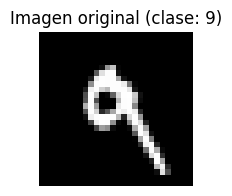

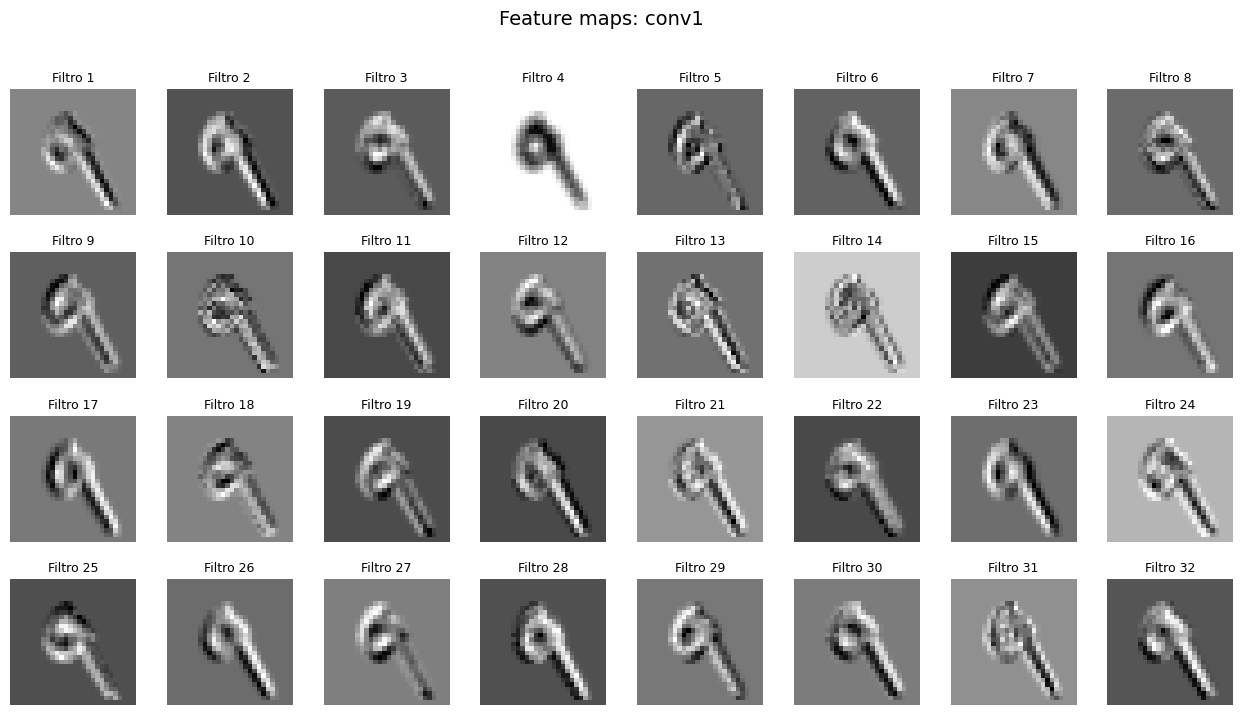

Guardado: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras-mnist-features/conv1.png


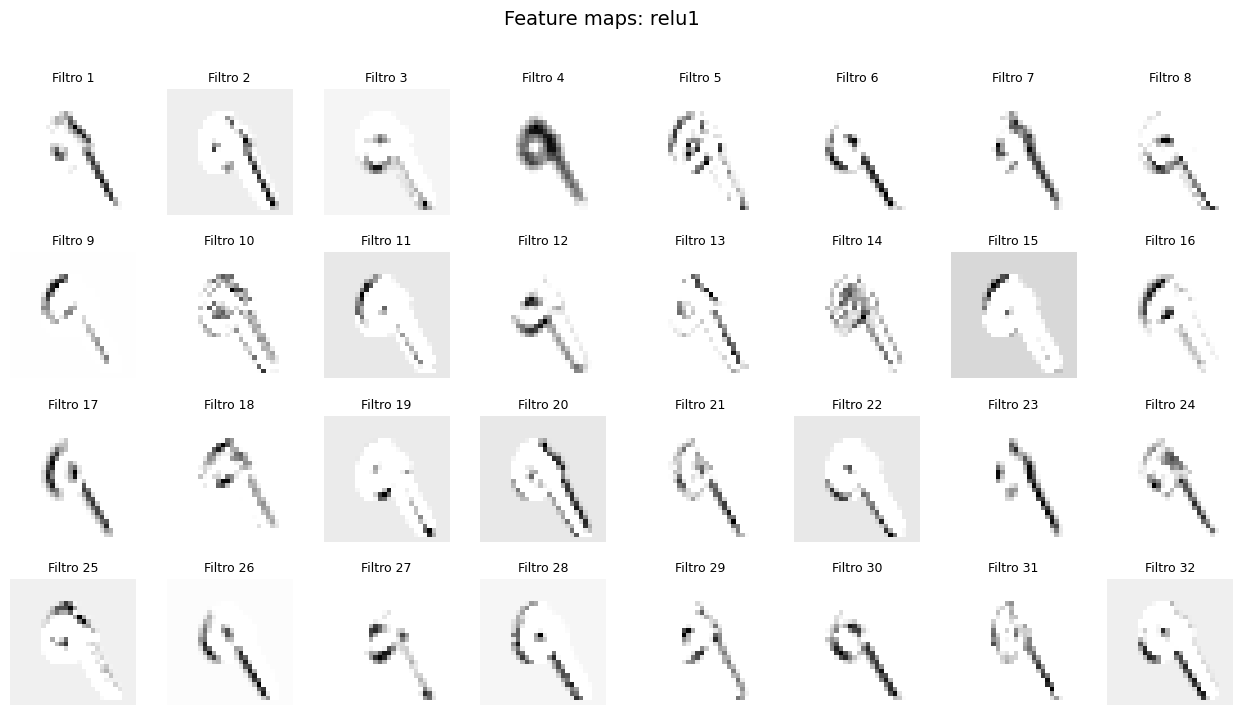

Guardado: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras-mnist-features/relu1.png


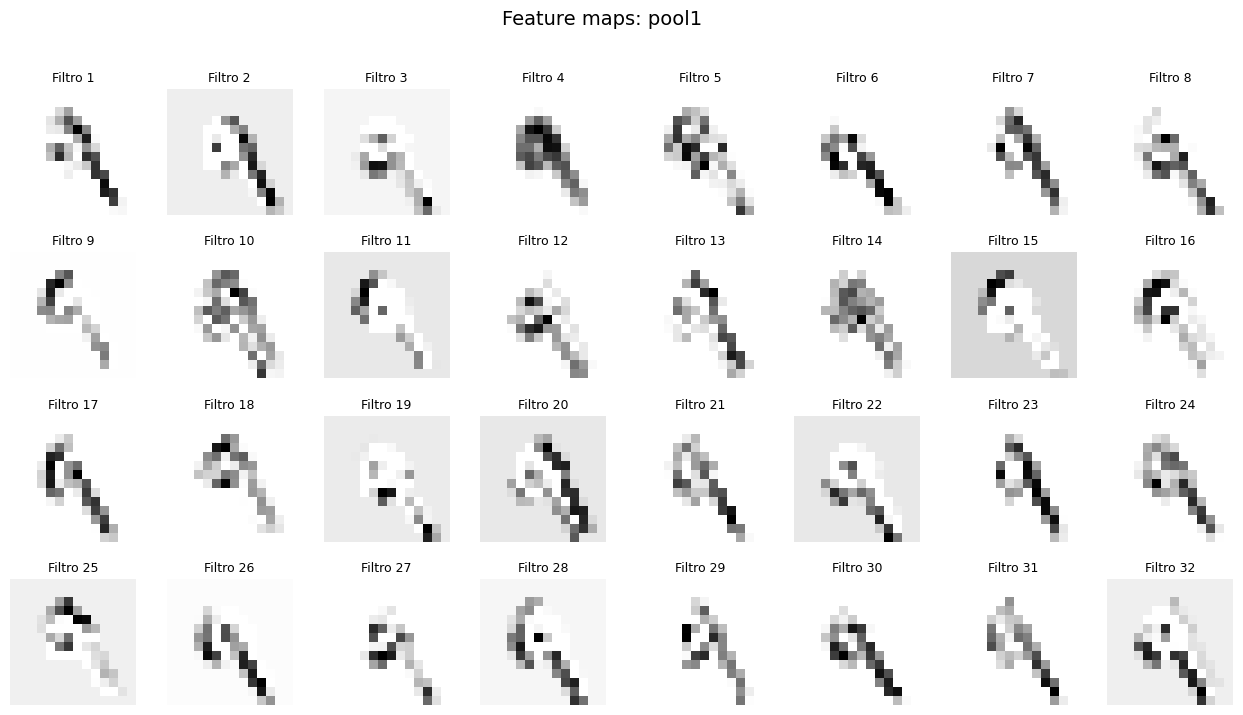

Guardado: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras-mnist-features/pool1.png


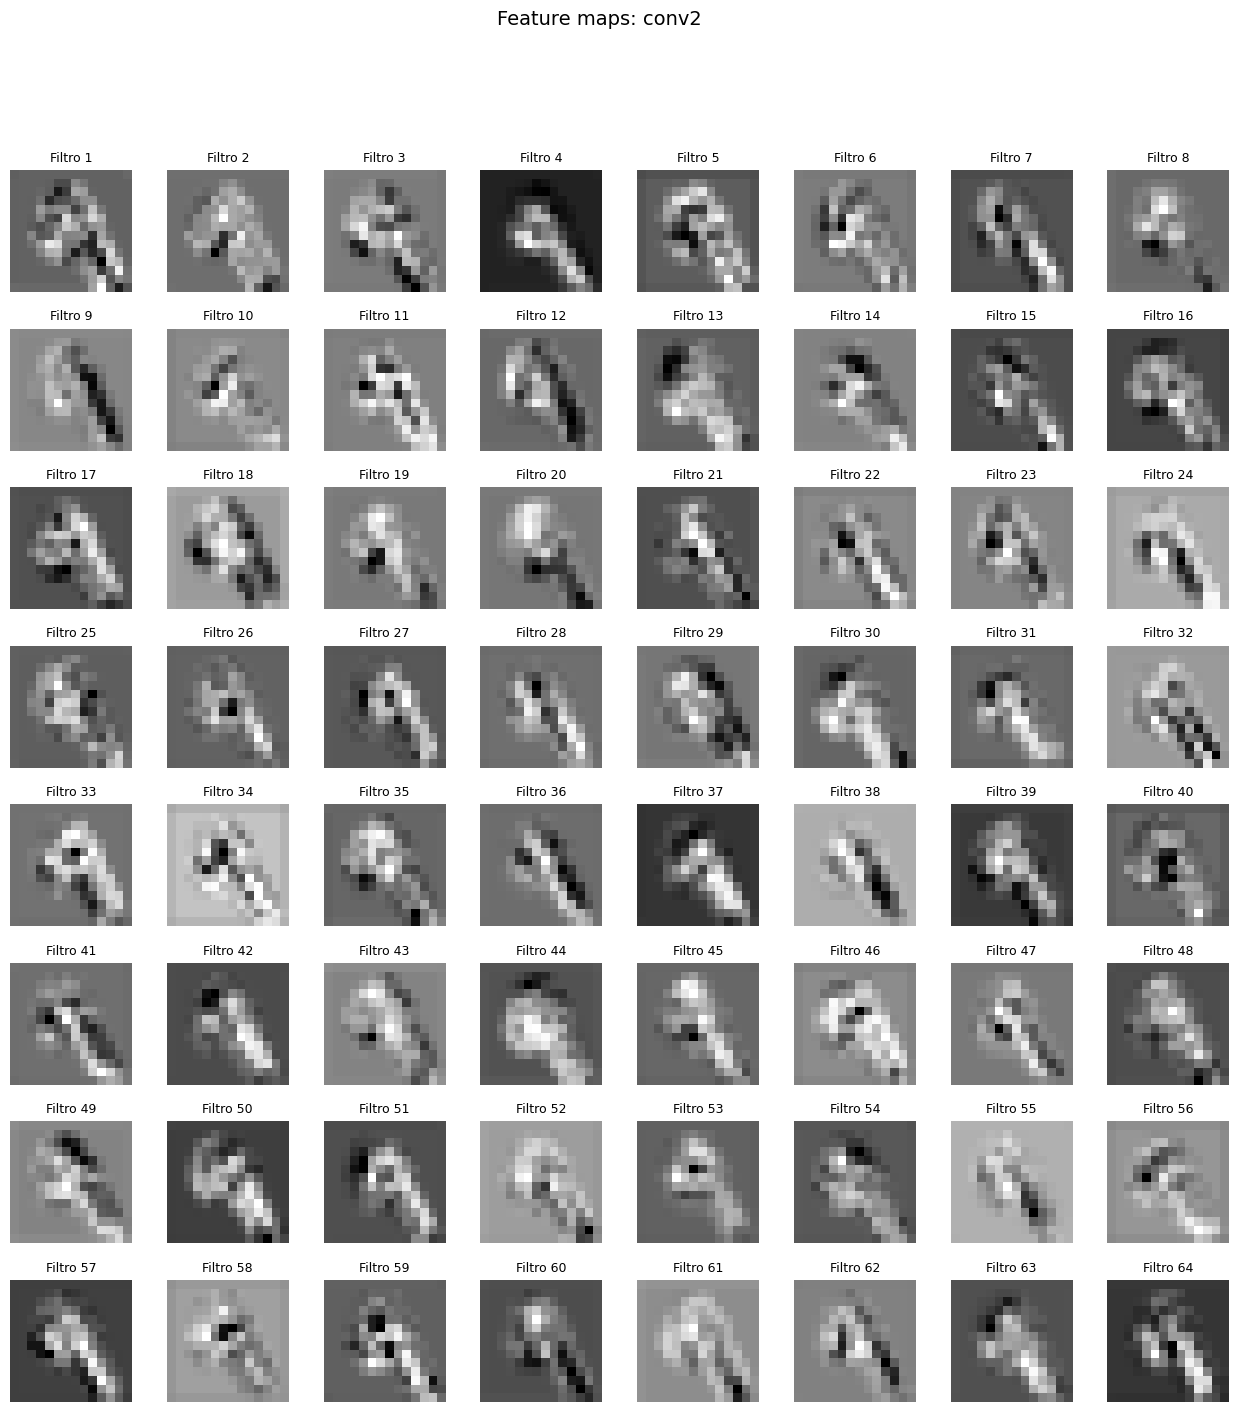

Guardado: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras-mnist-features/conv2.png


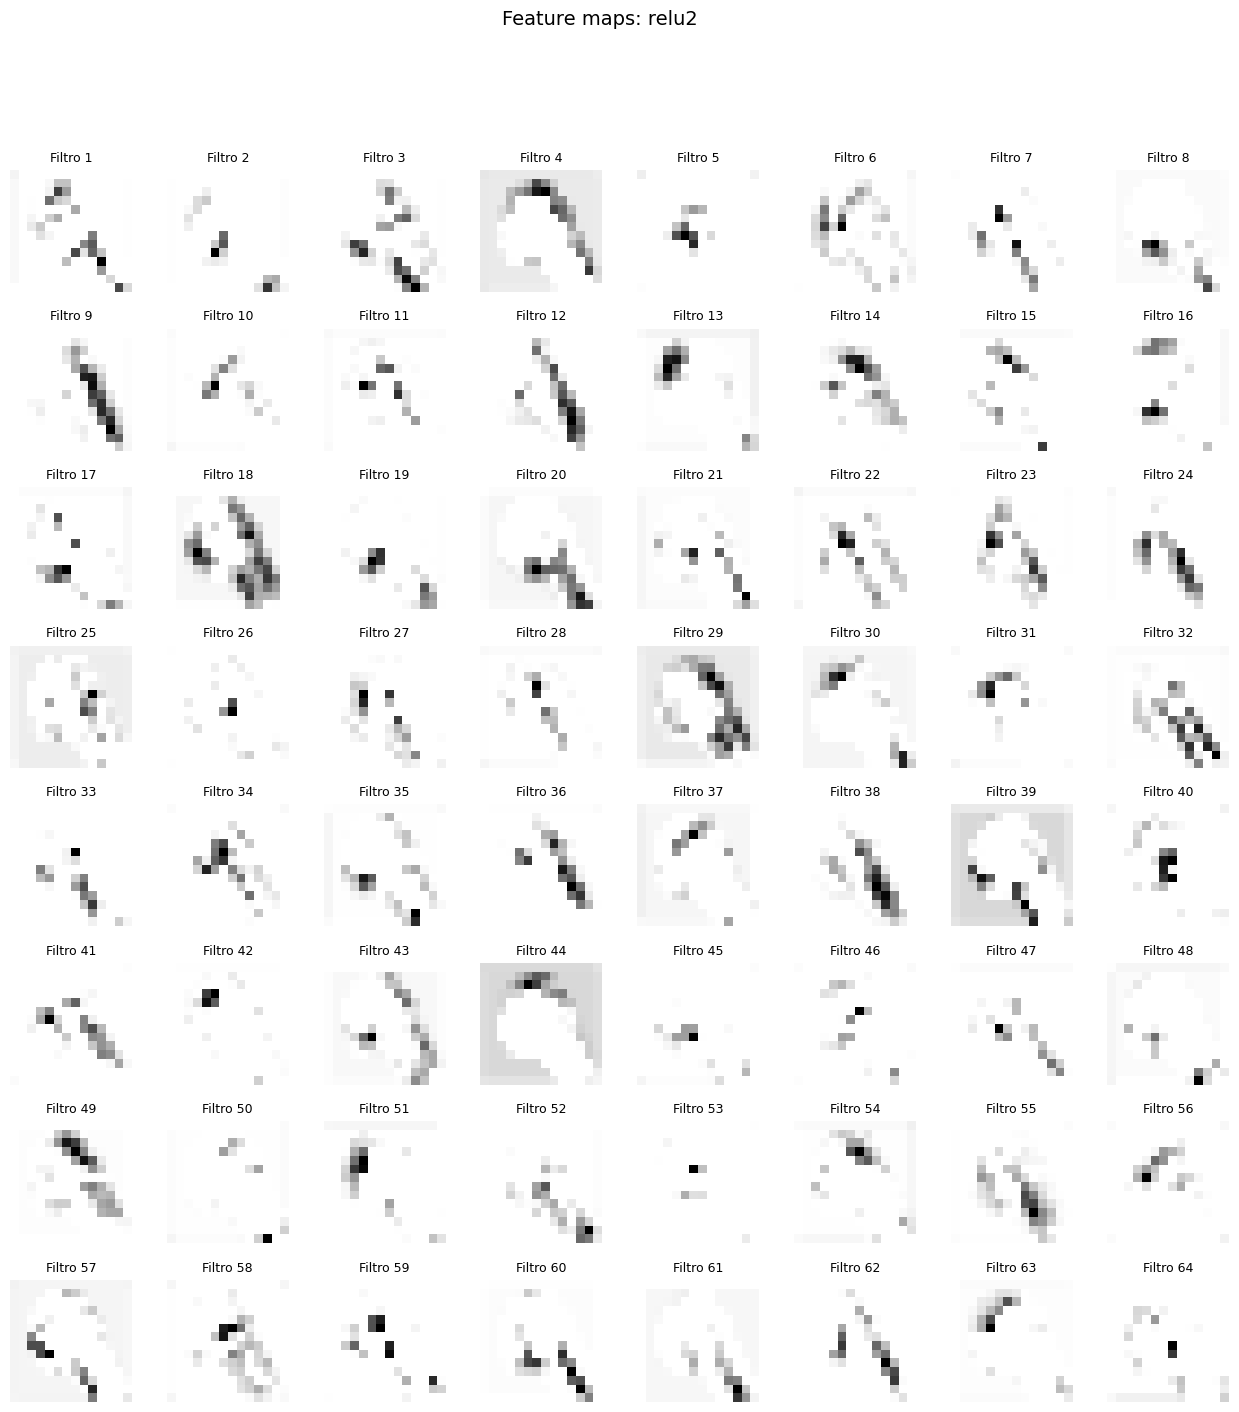

Guardado: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras-mnist-features/relu2.png


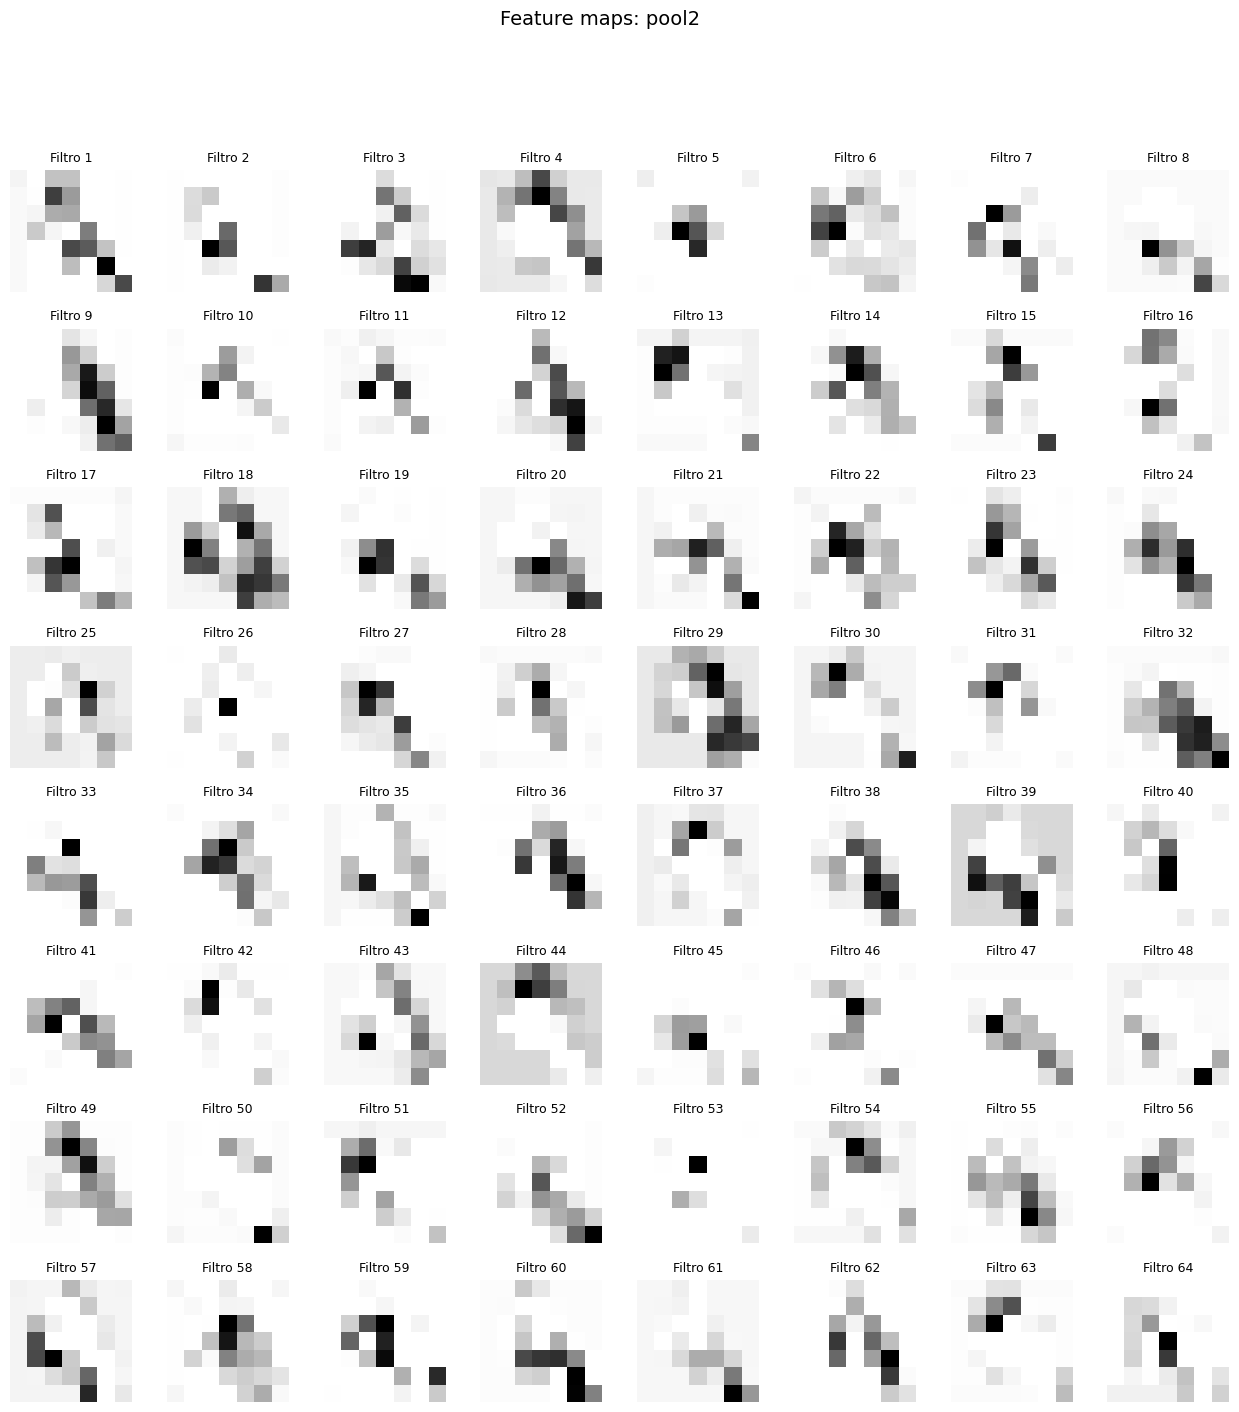

Guardado: /home/eze/IA-BigData/M03/RA2/T3/ACT_OBL_03/keras-mnist-features/pool2.png


In [14]:
def plot_feature_maps(activation, layer_name, img_dir, n_cols=8):
    """Visualiza los feature maps de una capa convolucional o de pooling."""
    acts = activation[0]  # (H, W, C): quitar dimensión de batch
    n_filtros = acts.shape[-1]
    n_rows = (n_filtros + n_cols - 1) // n_cols  # ceil division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
    axes = axes.flatten()

    for i in range(n_filtros):
        axes[i].imshow(acts[:, :, i].numpy(), cmap="binary")
        axes[i].axis("off")
        axes[i].set_title(f"Filtro {i + 1}", fontsize=9)

    # Ocultar ejes sobrantes si n_filtros no llena la cuadrícula
    for j in range(n_filtros, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Feature maps: {layer_name}", fontsize=14)
    plt.subplots_adjust(top=0.88, hspace=0.3, wspace=0.1)
    filepath = os.path.join(img_dir, f"{layer_name}.png")
    plt.savefig(filepath, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {filepath}")


# Mostrar la imagen original
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(sample_img[0, :, :, 0], cmap="gray")
ax.set_title(f"Imagen original (clase: {y_test[sample_idx]})")
ax.axis("off")
plt.savefig(os.path.join(img_dir, "imagen_original.png"), dpi=150, bbox_inches="tight")
plt.show()

# Visualizar feature maps capa a capa
for capa_nombre, activacion in zip(capas_a_visualizar, activations):
    plot_feature_maps(activacion, capa_nombre, img_dir)

## Análisis de los feature maps

El proceso de extracción de características sigue la misma lógica que en el Ejercicio 2, pero con diferencias arquitectónicas notables: esta CNN usa 32 y 64 filtros (frente a 16 y 32 en PyTorch), incluye BatchNormalization y aplica data augmentation durante el entrenamiento.

### conv1 — Primeras características (28×28, 32 filtros)
Cada uno de los 32 filtros aprende a detectar un patrón básico sobre la imagen original: bordes horizontales, verticales, diagonales, cambios de intensidad, curvas simples. El `padding='same'` mantiene la resolución espacial en 28×28.

### relu1 — Eliminación de negativos
ReLU pone a 0 todos los valores negativos. Las zonas oscuras desaparecen y el contraste aumenta. La red empieza a enfocarse en lo relevante para cada filtro: solo se conservan las zonas donde el patrón del filtro está presente.

### pool1 — Primera reducción espacial (14×14)
MaxPooling 2×2 reduce de 28×28 a 14×14 conservando el máximo de cada región. Las imágenes se ven más comprimidas pero las activaciones más fuertes se mantienen. El modelo gana invarianza a pequeñas traslaciones.

### conv2 — Patrones más complejos (14×14, 64 filtros)
Ahora los 64 filtros trabajan sobre representaciones ya procesadas, no sobre píxeles crudos. Aprenden combinaciones de patrones básicos: formas curvas, bucles y formas abstractas típicas de cada dígito. Las activaciones son más abstractas y menos parecidas a la imagen original.

### relu2 — Segunda activación
Igual que antes: elimina negativos. Las activaciones son más selectivas y definidas. La red filtra lo que no aporta al reconocimiento del dígito.

### pool2 — Segunda reducción espacial (7×7)
MaxPooling 2×2 reduce de 14×14 a 7×7. En este punto, la representación es compacta: 64 mapas de 7×7 = 3136 valores. Esta es la representación que el clasificador denso usará para distinguir entre los 10 dígitos.

### Diferencias clave respecto al Ejercicio 2 (PyTorch)
- Mayor número de filtros (32/64 frente a 16/32): representaciones más ricas en cada capa.
- **BatchNormalization** entre convolución y activación: estabiliza la distribución de activaciones y acelera la convergencia.
- **Dropout(0.4)** en la capa densa: regularización más agresiva que reduce el sobreajuste.
- La extracción de activaciones intermedias se hace con `tf.keras.Model(inputs, outputs=[...])`, más directa que los hooks de PyTorch.

## Conclusiones

La CNN de Keras/TensorFlow logra el mejor resultado de los tres ejercicios con un **99.38% de accuracy**, gracias a tres mejoras sobre la arquitectura del Ejercicio 2:

- **Data augmentation** (rotación, zoom, traslación) integrada en el modelo: el modelo ve versiones ligeramente perturbadas de cada imagen durante el entrenamiento, mejorando la generalización a variaciones reales de escritura.
- **Batch Normalization**: normaliza las activaciones entre capas, estabilizando el entrenamiento y actuando como regularizador implícito.
- **Dropout (0.4)**: desactiva aleatoriamente el 40% de las neuronas de la capa densa durante el entrenamiento, forzando representaciones más distribuidas y robustas.

En cuanto al framework, Keras ofrece la implementación más concisa: `model.fit`, los callbacks de early stopping y scheduler, y la extracción de feature maps con `tf.keras.Model` son APIs de alto nivel que abstraen por completo el bucle manual de PyTorch. La contrapartida es menor visibilidad sobre cada paso del proceso.

En conjunto, los tres ejercicios ilustran un trade-off claro: **Scikit-learn** maximiza la simplicidad a costa de rendimiento, **PyTorch** ofrece control total con mayor verbosidad, y **Keras/TensorFlow** equilibra abstracción y rendimiento estado del arte.
